
<div style="text-align:center">
<img src="img/introml.png" width="600">
</div>

# Introduction

I'm going to summarize the basics of machine learning in Python, mainly with A.I, unlike my old stuff in French, that was hand made and using books.
Only real world problems, as always, supervized algorithms.

# Summary


Part 1 : Real world Regressions and classifications

01. <b>Machine-learning house-price prediction using linear regression.  </b>
    - Abstract
    - Instance
    - Math model
    - Python solution
02. <b>Machine-learning predicting whether a customer will leave a company (customer churn).  </b>
    - Abstract
    - Instance
    - Math model
    - Python solution
03. <b>Simple loan approval prediction</b>
    - Abstract
    - Instance
    - Math model
    - Python 
    
04. <b>Predicting the probability that a customer will buy a product based on the amount spent on advertising.</b>
    - Abstract
    - Instance
    - Math model
    - Python 

05. <b>Higher or lower disease risk based on age and blood pressure.</b>
    - Abstract
    - Instance
    - Math model
    - Python 

Part 2 : Decision tree classifiers

06. <b>Predicting whether a customer will buy a product based on their age and annual income</b>
    - Abstract
    - Instance
    - Math model
    - Python 

07. <b>Predicting whether a customer will buy a product based on their age, income, and website visits( Random forest).</b>
    - Abstract
    - Instance
    - Math model
    - Python 

Part 3 : K-neighbors and K-means

08. <b>Classifying a fruit as an apple or an orange based on its weight and size ( K-neighbors)</b>
    - Abstract
    - Instance
    - Math model
    - Python 

09. <b>Automatically find groups of similar customers , criters based ( K-means)</b>
    - Abstract
    - Instance
    - Math model
    - Python 





Part 3 : Image detection

Part 4 : Neural networks and Pytorch robotics 






# 1. Machine-learning house-price prediction using linear regression.  
<div align="center">
<img   src="img/GettyImages-509540570-0f613d77de3b40b28af6699f51b96874.jpg" width="800" height="300">
</div>

The simplest machine-learning house-price prediction in Python is linear regression.



In [332]:
from sklearn.linear_model import LinearRegression

# Training data
# [size in m²]
X = [[50], [70], [90], [110], [130]]

# House prices in €
y = [100000, 140000, 180000, 220000, 260000]

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Predict price for a 100 m² house
price = model.predict([[100]])

print("Predicted price:", price[0], "€")



Predicted price: 200000.0 €


What happens?

The model learns a simple relationship:

$$ \text{price} = a \times \text{size} + b $$

So after training, you can give it a new house size:

In [333]:
model.predict([[120]])

array([240000.])

and it predicts the price.

## Scatter points

<img src="img/Screenshot 2026-08-29 at 11-30-37 Quadratic Hospital Optimization.png" width="800" height="300">


## Slightly more realistic version

Use size + number of bedrooms:

In [334]:
from sklearn.linear_model import LinearRegression

# [size, bedrooms]
X = [
    [50, 1],
    [70, 2],
    [90, 2],
    [110, 3],
    [130, 4]
]

y = [100000, 150000, 190000, 240000, 300000]

model = LinearRegression()
model.fit(X, y)

# 100 m², 3 bedrooms
prediction = model.predict([[100, 3]])

print(f"Predicted price: €{prediction[0]:,.0f}")

Predicted price: €224,667


This is probably the best starting example if you're learning machine learning: small dataset → train model → give new house → get predicted price.

# 2. Machine-learning predicting whether a customer will leave a company (customer churn).

<div align="center">
<img src="img/Customer-Churn.png">

In [335]:
from sklearn.linear_model import LogisticRegression

# Training data
# [age, months_as_customer, monthly_bill]
X = [
    [25, 2, 80],
    [30, 5, 90],
    [45, 36, 50],
    [50, 48, 45],
    [28, 3, 100],
    [40, 24, 55]
]

# 1 = leaves, 0 = stays
y = [1, 1, 0, 0, 1, 0]

# Create and train model
model = LogisticRegression()
model.fit(X, y)

# New customer
customer = [[32, 6, 95]]

prediction = model.predict(customer)

if prediction[0] == 1:
    print("Customer may leave")
else:
    print("Customer likely stays")

Customer may leave


Why this is machine learning

Instead of writing a rule like:

"If the bill is greater than €90, the customer leaves."

we give the computer examples, and it learns a pattern from them.

Other very easy real-world examples are:


Problem	ML type<br>
🏠 House price	Regression<br>
📱 Customer churn	Classification<br>
📧 Spam email detection	Classification<br>
🏥 Disease-risk prediction	Classification<br>
🚗 Used-car price	Regression<br>
💳 Fraud detection	Classification<br>
⚡ Electricity consumption	Regression<br>
🛒 Product recommendation	Classification/recommendation<br>

# 3. Simple loan approval prediction

If you mean predict whether a person is likely to get a loan approved, a very simple machine-learning example is Logistic Regression.


In [336]:
from sklearn.linear_model import LogisticRegression

# [income (€), loan amount (€), credit score]
X = [
    [2000, 5000, 600],
    [2500, 7000, 650],
    [3000, 8000, 700],
    [4000, 10000, 750],
    [1500, 6000, 550],
    [5000, 12000, 800]
]

# 1 = approved, 0 = rejected
y = [0, 0, 1, 1, 0, 1]

# Train model
model = LogisticRegression()
model.fit(X, y)

# New applicant
applicant = [[3500, 15000, 720]]

# Prediction
prediction = model.predict(applicant)

# Probability / confidence
probability = model.predict_proba(applicant)

print("Prediction:", prediction[0])
print("Probability of approval:", probability[0][1])
print("Probability of rejection:", probability[0][0])

Prediction: 0
Probability of approval: 1.1125919788849311e-23
Probability of rejection: 1.0


# 4. Probability that a customer will buy a product based on the amount spent on advertising

<div align="center">
<img src="img/outdoor-advertising-design-abstract-concept_335657-3077.avif" width="800" height="300">

We can use Logistic Regression and a scatter plot showing the actual sales outcomes.

In [337]:

from sklearn.linear_model import LogisticRegression

# Advertising budget (€)
X = [[10], [20], [30], [40], [50],
     [60], [70], [80], [90], [100]]

# Sales outcome
# 0 = No sale
# 1 = Sale
y = [0, 0, 0, 0, 0,
     1, 1, 1, 1, 1]

# Create and train the model
model = LogisticRegression()
model.fit(X, y)

# Predict probability of a sale
advertising = [[65]]

probability = model.predict_proba(advertising)

print(f"Probability of sale: {probability[0][1] * 100:.1f}%")

Probability of sale: 99.7%


2. Draw the scatter points

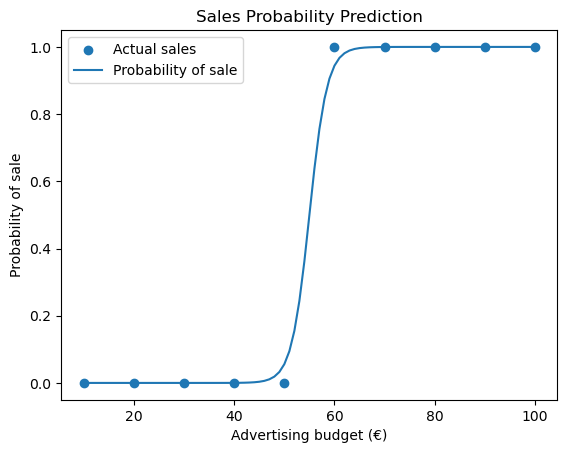

In [338]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

X = [[10], [20], [30], [40], [50],
     [60], [70], [80], [90], [100]]

y = [0, 0, 0, 0, 0,
     1, 1, 1, 1, 1]

model = LogisticRegression()
model.fit(X, y)

# Values for the probability curve
x_values = [[x] for x in range(10, 101)]

# Probability of sale
probabilities = model.predict_proba(x_values)[:, 1]

# Actual data points
plt.scatter(X, y, label="Actual sales")

# Machine-learning probability curve
plt.plot(
    [x[0] for x in x_values],
    probabilities,
    label="Probability of sale"
)

plt.xlabel("Advertising budget (€)")
plt.ylabel("Probability of sale")
plt.title("Sales Probability Prediction")
plt.legend()
plt.show()

 # 5. Higher or lower disease risk based on age and blood pressure.

<div align="center">
 <img src="img/person-using-tensiometer-blood-pressure_23-2150456068.avif" width="800" height="300">

 For a basic machine-learning exercise, we can predict whether someone is at higher or lower disease risk based on age and blood pressure. We'll use Logistic Regression and a scatter plot.

This is only an educational example with invented data, not a medical prediction tool.

Prediction: 1
Probability of higher risk: 99.0%


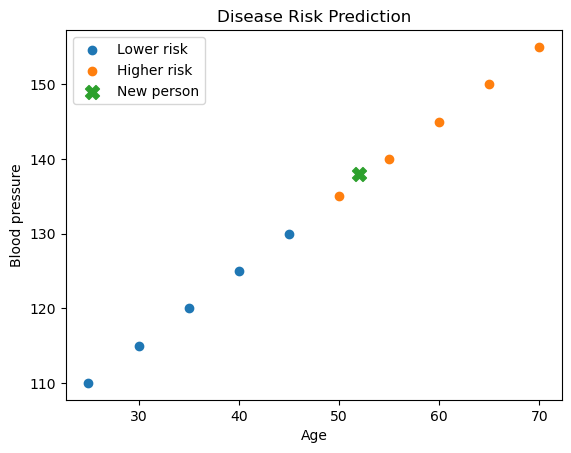

In [339]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Data
# [Age, Blood Pressure]
X = [
    [25, 110],
    [30, 115],
    [35, 120],
    [40, 125],
    [45, 130],
    [50, 135],
    [55, 140],
    [60, 145],
    [65, 150],
    [70, 155]
]

# 0 = Lower risk
# 1 = Higher risk
y = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

# Create the machine-learning model
model = LogisticRegression()

# Train the model
model.fit(X, y)

# New person
person = [[52, 138]]

# Predict risk
prediction = model.predict(person)

# Probability
probability = model.predict_proba(person)

print("Prediction:", prediction[0])

print(
    f"Probability of higher risk: "
    f"{probability[0][1] * 100:.1f}%"
)

# --------------------------------
# Scatter plot
# --------------------------------

# Separate lower and higher risk
low_risk = [X[i] for i in range(len(X)) if y[i] == 0]
high_risk = [X[i] for i in range(len(X)) if y[i] == 1]

# Plot the points
plt.scatter(
    [p[0] for p in low_risk],
    [p[1] for p in low_risk],
    label="Lower risk"
)

plt.scatter(
    [p[0] for p in high_risk],
    [p[1] for p in high_risk],
    label="Higher risk"
)

# New person
plt.scatter(
    person[0][0],
    person[0][1],
    marker="X",
    s=100,
    label="New person"
)

plt.xlabel("Age")
plt.ylabel("Blood pressure")
plt.title("Disease Risk Prediction")
plt.legend()
plt.show()

# 6. Predicting whether a customer will buy a product based on their age and annual income


<div align="center">
 <img src="img/smartphone_customer_demographic_with_age_breakdown_slide01.jpg" width="800" height="300">
</div>

A simple real-life Decision Tree example is predicting whether a customer will buy a product based on their age and annual income.

The decision tree learns rules such as:

If income is high → likely to buy.
If income is low → likely not to buy.

This is a classification problem.

Customer is unlikely to buy
Probability of buying: 0.0%


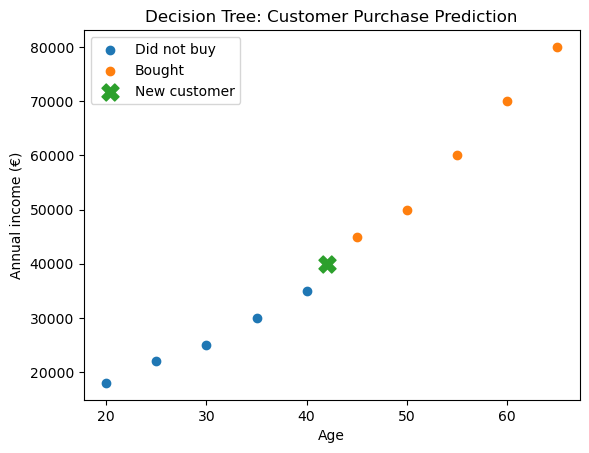

In [340]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Data
# [Age, Annual Income (€)]
X = [
    [20, 18000],
    [25, 22000],
    [30, 25000],
    [35, 30000],
    [40, 35000],
    [45, 45000],
    [50, 50000],
    [55, 60000],
    [60, 70000],
    [65, 80000]
]

# 0 = Did not buy
# 1 = Bought
y = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

# Create Decision Tree
model = DecisionTreeClassifier(max_depth=2)

# Train the model
model.fit(X, y)

# New customer
customer = [[42, 40000]]

# Prediction
prediction = model.predict(customer)

# Probability
probability = model.predict_proba(customer)

if prediction[0] == 1:
    print("Customer is likely to buy")
else:
    print("Customer is unlikely to buy")

print(
    f"Probability of buying: "
    f"{probability[0][1] * 100:.1f}%"
)

# -------------------------
# Scatter plot
# -------------------------

# Customers who did not buy
not_buy = [X[i] for i in range(len(X)) if y[i] == 0]

# Customers who bought
buy = [X[i] for i in range(len(X)) if y[i] == 1]

# Plot "did not buy"
plt.scatter(
    [p[0] for p in not_buy],
    [p[1] for p in not_buy],
    label="Did not buy"
)

# Plot "bought"
plt.scatter(
    [p[0] for p in buy],
    [p[1] for p in buy],
    label="Bought"
)

# Plot new customer
plt.scatter(
    customer[0][0],
    customer[0][1],
    marker="X",
    s=150,
    label="New customer"
)

plt.xlabel("Age")
plt.ylabel("Annual income (€)")
plt.title("Decision Tree: Customer Purchase Prediction")
plt.legend()
plt.show()

📊 What the scatter plot shows

Each dot is a customer:

Age → horizontal axis
Income → vertical axis
One group → customers who bought
Another group → customers who didn't buy
X → the new customer we're predicting

🌳 What the Decision Tree is doing

The tree might learn a structure similar to:

             Income > €40,000?
                  /       \
                NO         YES
                /           \
          Don't buy       Buy

Unlike linear regression, the decision tree doesn't try to draw one straight line through the points. It learns if/then rules that divide the data into groups.

You can also draw the actual decision tree with plot_tree():

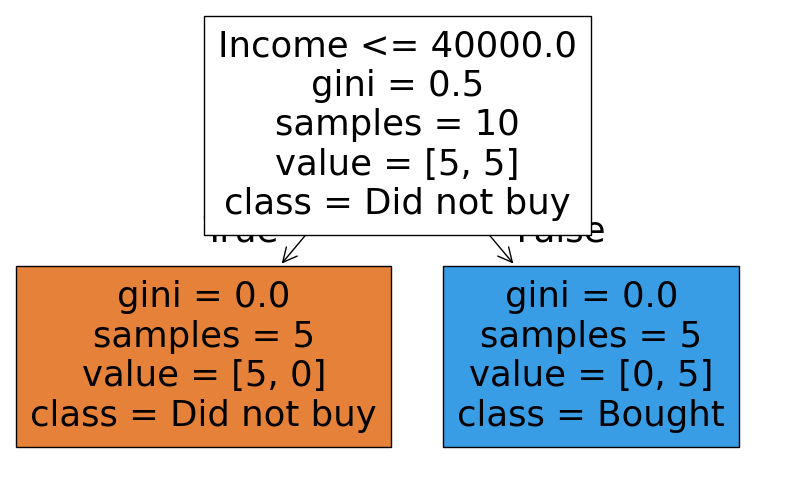

In [341]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))

plot_tree(
    model,
    feature_names=["Age", "Income"],
    class_names=["Did not buy", "Bought"],
    filled=True
)

plt.show()

That gives you a visual representation of the rules the machine-learning model learned.

# 07 . Predicting whether a customer will buy a product based on their age, income, and website visits.

Random Forest is useful because it combines many decision trees to make one prediction.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Data
# [Age, Annual income (€), Website visits]
X = [
    [20, 18000, 2],
    [25, 22000, 3],
    [30, 25000, 4],
    [35, 30000, 5],
    [40, 35000, 6],
    [45, 45000, 8],
    [50, 50000, 10],
    [55, 60000, 12],
    [60, 70000, 15],
    [65, 80000, 18]
]

# 0 = Did not buy
# 1 = Bought
y = [0, 0, 0, 0, 0,
     1, 1, 1, 1, 1]

# Create Random Forest
model = RandomForestClassifier(
    n_estimators=10,
    random_state

# 8. Classifying a fruit as an apple or an orange based on its weight and size



<div align="center">
 <img src="img/1-s2.0-S0168169921002842-fx3.jpg" width="500" >
</div>

A very easy real-world K-Nearest Neighbors (KNN) example is classifying a fruit as an apple or an orange based on its weight and size.

KNN looks at the closest existing examples and asks: "What are most of the nearby examples?"

The fruit is probably an Apple


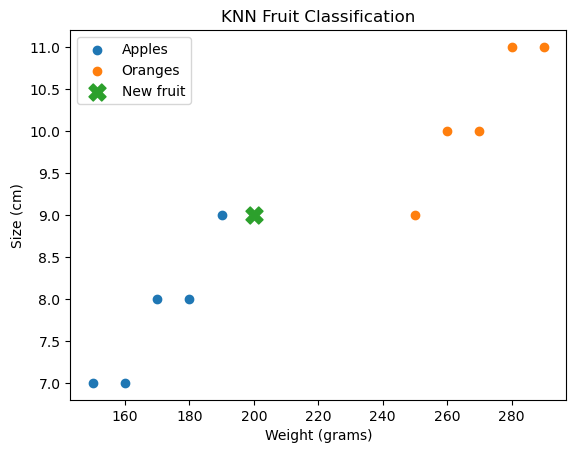

In [342]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Data
# [Weight (grams), Size (cm)]
X = [
    [150, 7],
    [160, 7],
    [170, 8],
    [180, 8],
    [190, 9],       # Apples

    [250, 9],
    [260, 10],
    [270, 10],
    [280, 11],
    [290, 11]       # Oranges
]

# 0 = Apple
# 1 = Orange
y = [0, 0, 0, 0, 0,
     1, 1, 1, 1, 1]

# Create KNN model
# Look at the 3 nearest neighbors
model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X, y)

# New fruit
new_fruit = [[200, 9]]

# Prediction
prediction = model.predict(new_fruit)

if prediction[0] == 0:
    print("The fruit is probably an Apple")
else:
    print("The fruit is probably an Orange")

# -------------------------
# Scatter graph
# -------------------------

# Apples
apples = [X[i] for i in range(len(X)) if y[i] == 0]

# Oranges
oranges = [X[i] for i in range(len(X)) if y[i] == 1]

# Plot apples
plt.scatter(
    [p[0] for p in apples],
    [p[1] for p in apples],
    label="Apples"
)

# Plot oranges
plt.scatter(
    [p[0] for p in oranges],
    [p[1] for p in oranges],
    label="Oranges"
)

# Plot new fruit
plt.scatter(
    new_fruit[0][0],
    new_fruit[0][1],
    marker="X",
    s=150,
    label="New fruit"
)

plt.xlabel("Weight (grams)")
plt.ylabel("Size (cm)")
plt.title("KNN Fruit Classification")
plt.legend()
plt.show()

The X in your Python graph is the new fruit:

new_fruit = [[200, 9]]<br>

<br>

KNN finds the 3 closest fruits to that point and uses their classifications to make the prediction.

🧠 The basic idea<br>


New fruit<br>
   ↓<br>
Find 3 nearest fruits<br>
   ↓<br>
Look at their classes<br>
   ↓<br>
Majority wins<br>
   ↓<br>
Apple or Orange<br>

This is a nice beginner example because you can see KNN working directly on the scatter plot.<br>

# 09. <b>Automatically find groups of similar customers , criters based ( K-means)</b>

<div align="center">
 <img src="img/user-group-icon-logo-illustration-customer-symbol-template-for-graphic-and-web-design-collection-vector.jpg"  >
</div>

A very simple real-world K-Means example is customer segmentation.

Imagine a shop wants to group its customers based on:

- Annual spending (€)
- Number of purchases per year

K-Means will automatically find groups of similar customers.

🛍️ K-Means customer segmentation

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Customer: [500, 5] → Group: 2
Customer: [600, 6] → Group: 2
Customer: [700, 7] → Group: 2
Customer: [800, 8] → Group: 2
Customer: [2000, 20] → Group: 0
Customer: [2200, 22] → Group: 0
Customer: [2400, 24] → Group: 0
Customer: [2500, 25] → Group: 0
Customer: [5000, 45] → Group: 1
Customer: [5200, 47] → Group: 1
Customer: [5500, 50] → Group: 1
Customer: [5800, 52] → Group: 1


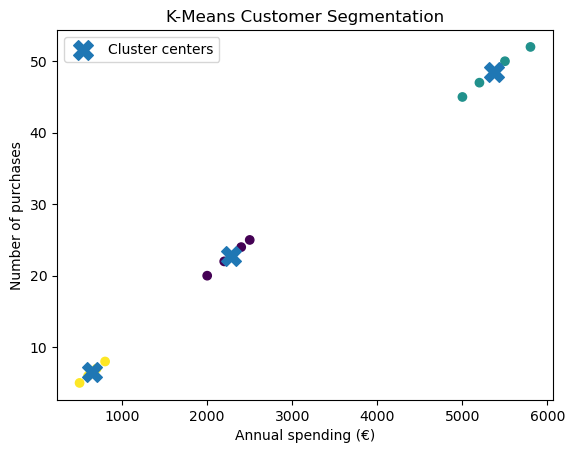

In [343]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Data
# [Annual spending (€), Number of purchases]
X = [
    [500, 5],
    [600, 6],
    [700, 7],
    [800, 8],

    [2000, 20],
    [2200, 22],
    [2400, 24],
    [2500, 25],

    [5000, 45],
    [5200, 47],
    [5500, 50],
    [5800, 52]
]

# Create K-Means model
# We want 3 customer groups
model = KMeans(n_clusters=3, random_state=42, n_init=10)

# Train the model
model.fit(X)

# Get cluster numbers
clusters = model.labels_

# Print results
for i in range(len(X)):
    print(
        "Customer:", X[i],
        "→ Group:", clusters[i]
    )

# -------------------------
# Scatter graph
# -------------------------

plt.scatter(
    [customer[0] for customer in X],
    [customer[1] for customer in X],
    c=clusters
)

# Plot cluster centers
centers = model.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200,
    label="Cluster centers"
)

plt.xlabel("Annual spending (€)")
plt.ylabel("Number of purchases")
plt.title("K-Means Customer Segmentation")

plt.legend()
plt.show()

🧠 What does K-Means actually do?

We tell it:

n_clusters=3

Then K-Means roughly does:

             Customer data
                   ↓
          Choose 3 cluster centers
                   ↓
       Find closest center for each
             customer
                   ↓
        Recalculate the centers
                   ↓
             Repeat
                   ↓
          3 customer groups

For example, it might discover:

Group |	Type of customer<br>
0	| Low spending / few purchases<br>
1	| Medium spending / regular purchases<br>
2	| High spending / frequent purchases<br>

The important thing about K-Means is that we don't give it the groups beforehand. Unlike classification with KNN or Decision Trees, we don't provide y labels such as "low", "medium", or "high".

That's why K-Means is an example of unsupervised machine learning.